In [2]:
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv(r"../../dataset/restaurant.csv")
df=df.dropna()
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [4]:
df["Price range"].head(10)

0    3
1    3
2    4
3    4
4    4
5    3
6    4
7    4
8    4
9    3
Name: Price range, dtype: int64

In [5]:
df['Price range'].value_counts().sort_index()

Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

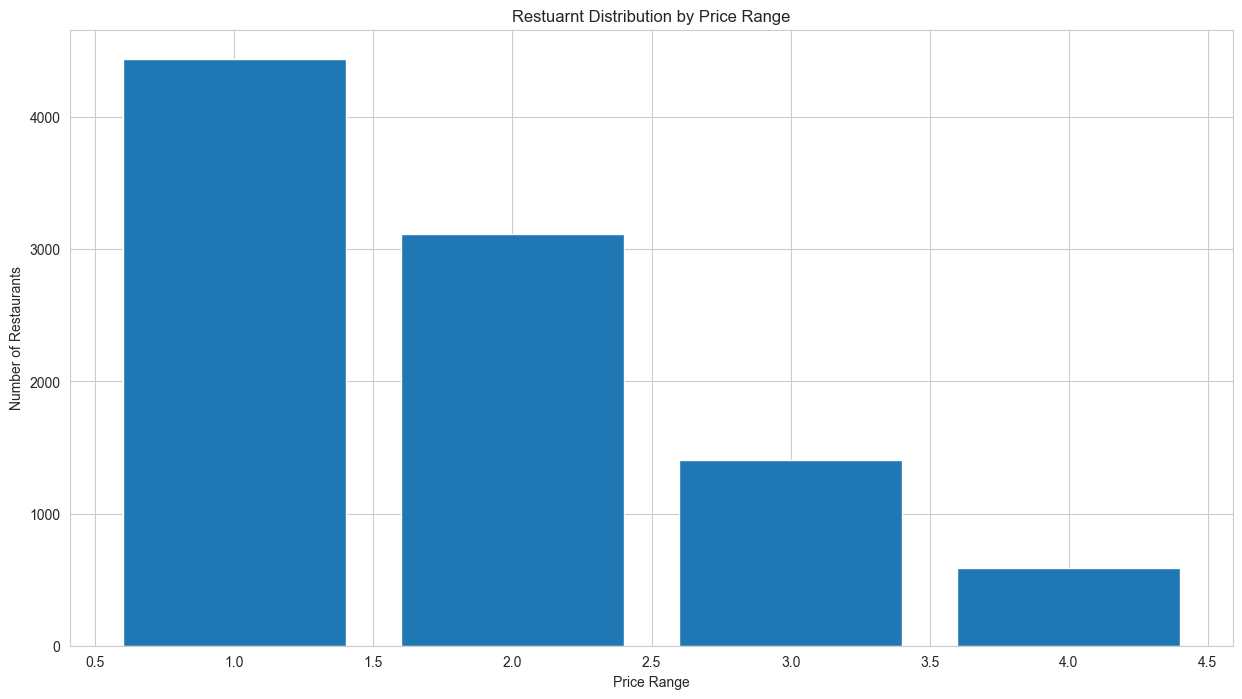

In [6]:
plt.figure(figsize=(15,8))
plt.bar(
    df['Price range'].value_counts().sort_index().index,
    df['Price range'].value_counts().sort_index().values
)
plt.title("Restuarnt Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

In [7]:
price_precentage=df['Price range'].value_counts(normalize=True).sort_index()*100

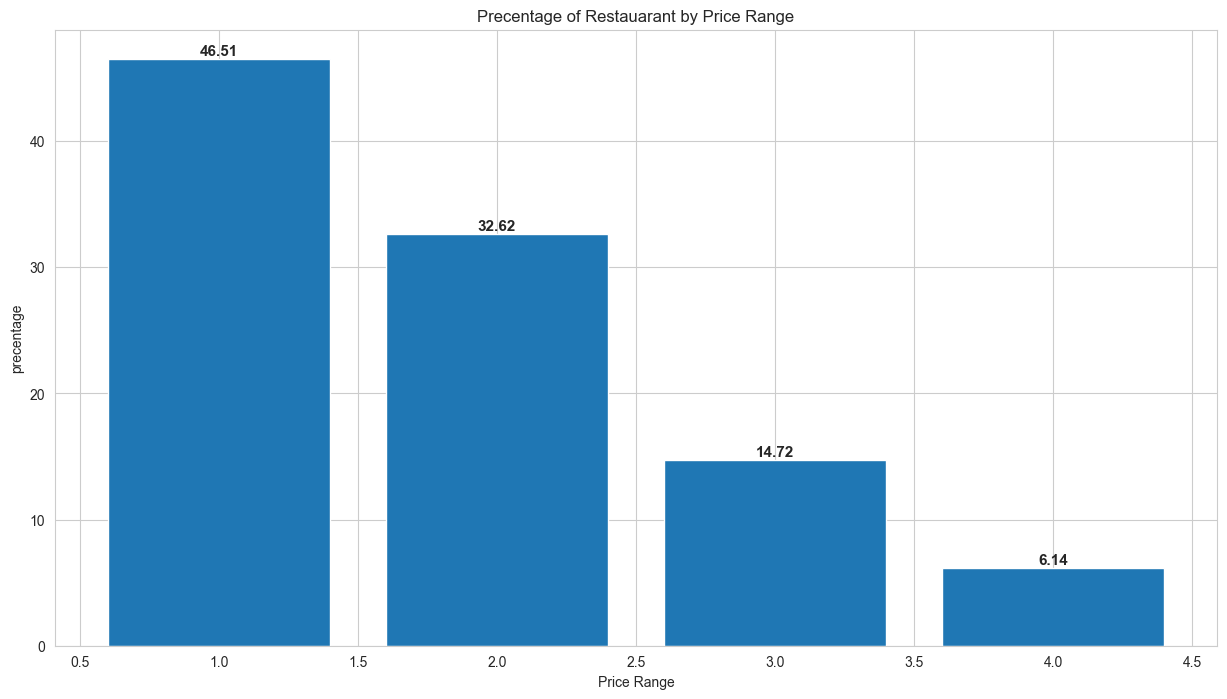

In [8]:
plt.figure(figsize=(15,8))
bars=plt.bar(
    price_precentage.index,
    price_precentage.values
)
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.05,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
plt.title("Precentage of Restauarant by Price Range")
plt.xlabel("Price Range")
plt.ylabel("precentage")
plt.show()

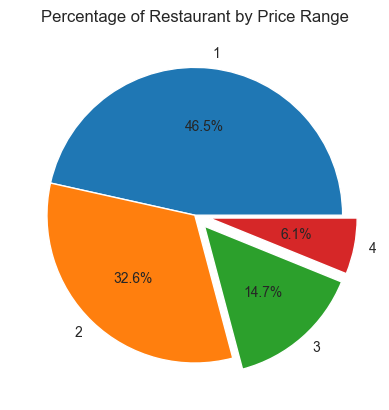

In [9]:
explode=[0,0,.1,.1]
plt.pie(price_precentage,labels=price_precentage.index,autopct='%.1f%%',explode=explode)
plt.title("Percentage of Restaurant by Price Range")
plt.show()

In [10]:
df.groupby('Price range')["Aggregate rating"].mean()

Price range
1    1.997476
2    2.941054
3    3.682633
4    3.817918
Name: Aggregate rating, dtype: float64

In [11]:
all_colors = plt.colormaps()
print(all_colors)



['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

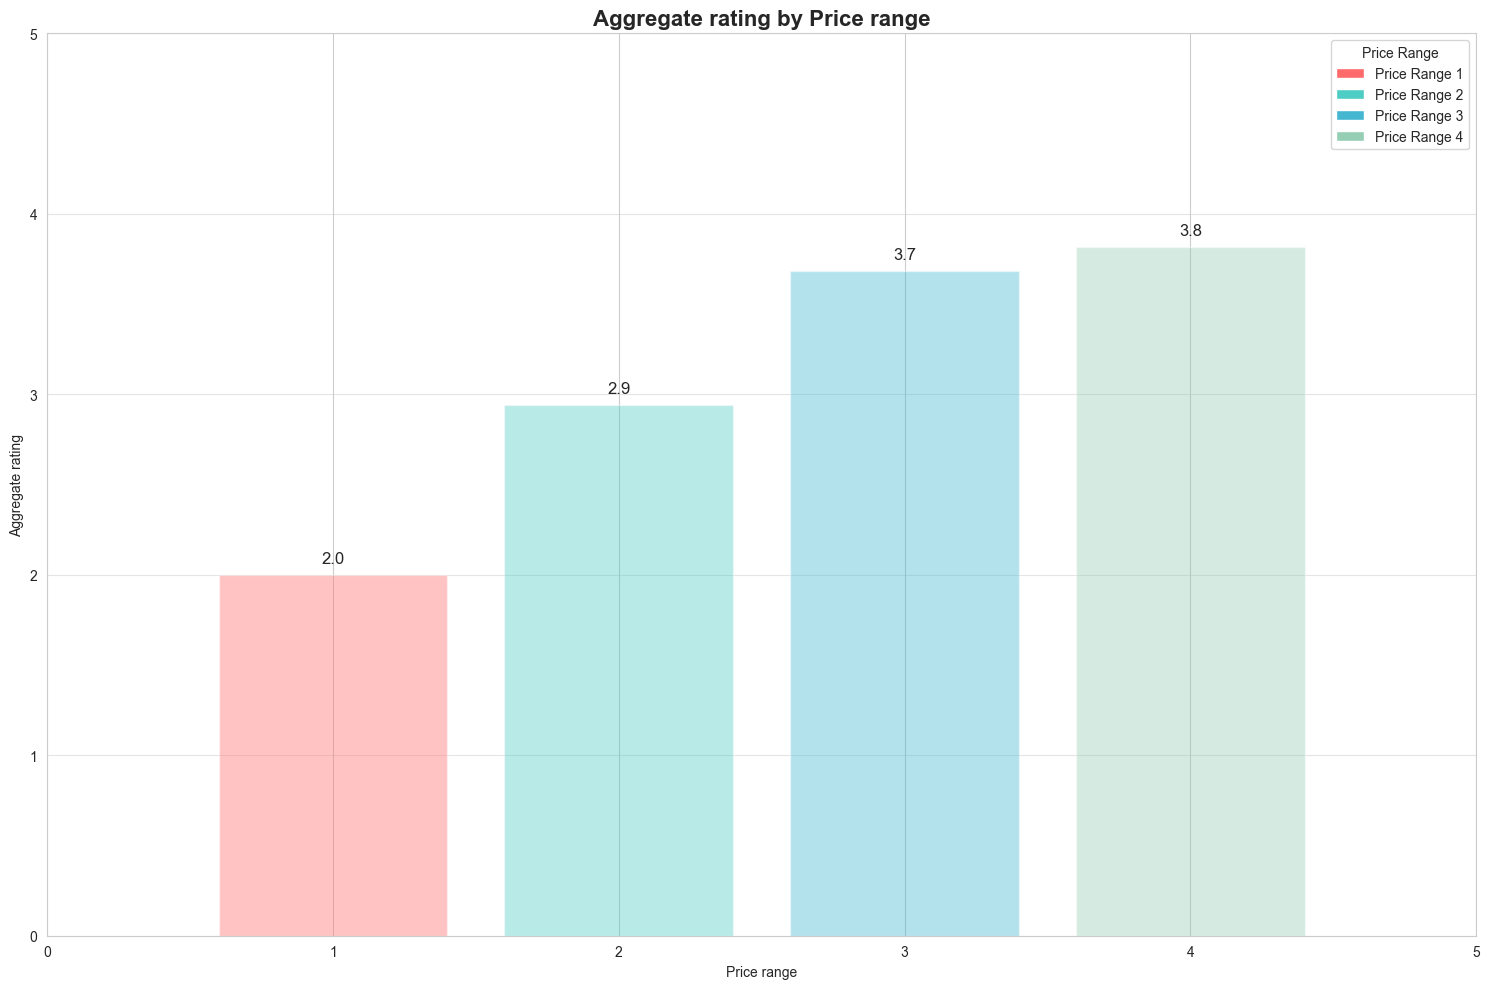

In [12]:
plt.figure(figsize=(15,10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars=plt.bar(
    df.groupby('Price range')["Aggregate rating"].mean().index,
    df.groupby('Price range')["Aggregate rating"].mean().values,
    color=colors,
    alpha=0.4,
    edgecolor="white",
    
)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2.,height+0.05,f'{height:.1f}',fontsize=12,ha='center', va='bottom')
legend=[
    Patch(facecolor=colors[0], label="Price Range 1"),
    Patch(facecolor=colors[1], label="Price Range 2"),
    Patch(facecolor=colors[2], label="Price Range 3"),
    Patch(facecolor=colors[3], label="Price Range 4")
]
plt.legend(handles=legend,title="Price Range",loc="upper right")
plt.ylim(0, 5)
plt.xlim(0,5)
plt.title("Aggregate rating by Price range",fontweight='bold',fontsize=16)
plt.ylabel("Aggregate rating")
plt.xlabel("Price range")
plt.tight_layout()
plt.grid(True, alpha=0.5, axis='y')
plt.show()

In [22]:
df.groupby("Price range")["Votes"].mean()

Price range
1     44.374493
2    147.607131
3    443.762989
4    368.595563
Name: Votes, dtype: float64

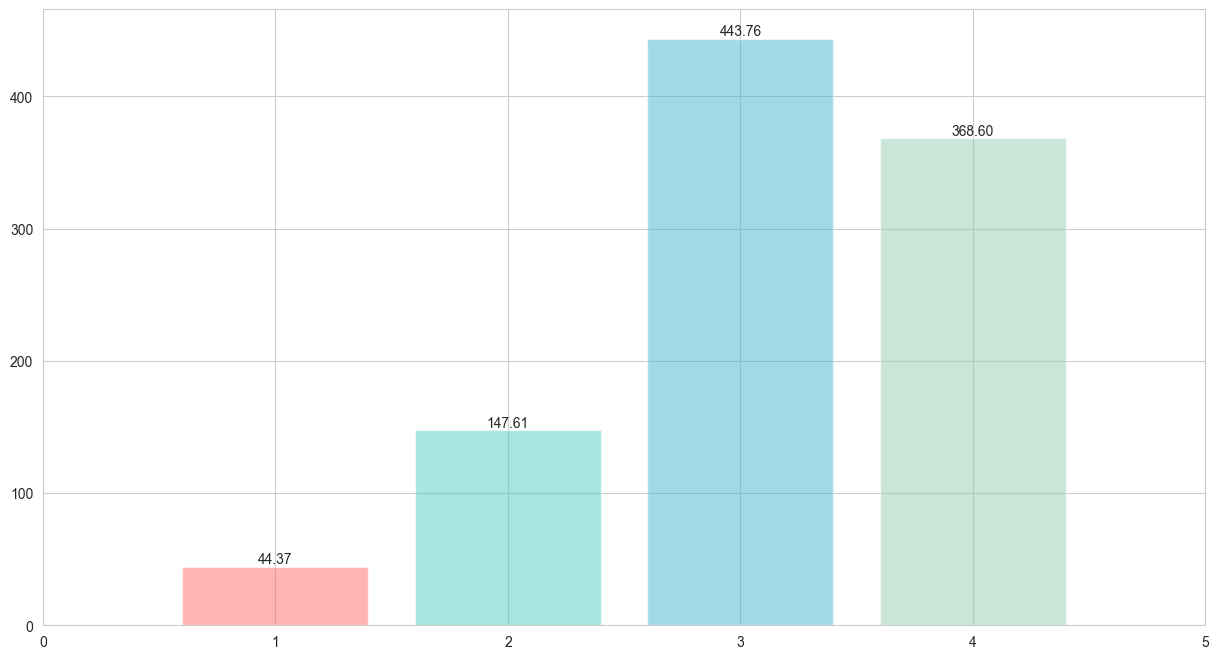

In [17]:
plt.figure(figsize=(15,8))
colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars=plt.bar(
    df.groupby("Price range")["Votes"].mean().index,
    df.groupby("Price range")["Votes"].mean().values,
    color=colors,
    alpha=0.5,
    edgecolor="white"
)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2.,height+0.05,f'{height:.2f}',ha='center',va='bottom')
plt.xlim(0,5)

plt.show()